# Optimizing Position along Z-axis

### Position Dictionary
```
{'x': 0.0001729267, 'y': 2.8033e-05, 'z': 0.0001018735}
```

In [170]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
import cv2
import torch
import torch.nn.functional as F
import time

In [171]:
spad = camera_SPC3
spad._Nrows = 32
spad._Ncols = 32
spad._apply_camera_settings()

piezo = scanning_probe_logic

laser = dlnsec_laser

## Subtract Background

### Laser States
- OFF = 0
- ON = 1
- LOCKED = 2
- UNKNOWN = 3

In [172]:
def take_bg_image(spad, laser, n_bg_frames=100):
    spad._NFrames = n_bg_frames

    laser.set_laser_state(0) # turn laser off    
    time.sleep(1)  # wait a moment to ensure laser is off


    success = spad.capture_background_image()
    spad.enable_background_subtraction()
    spad._NFrames = 1 

    laser.set_laser_state(1) # turn laser on

    if success == False:
        raise RuntimeError("Failed to capture background image.")
    else:
        print("Background image captured successfully.")
    
    h, w = spad.get_size()
    bg_frame = spad._background_image.reshape(h, w)

    time.sleep(1)  # wait a moment to ensure laser is back on

    return bg_frame # flattened background image

def get_frames(spad, n_frames=1):
    spad._NFrames = n_frames
    frames = spad.start_single_acquisition().squeeze()
    
    frames = np.array(frames).astype('float32')

    if spad._background_subtraction_enabled:
        if not hasattr(spad, "_background_image") or spad._background_image is None:
            raise ValueError("Background subtraction is enabled, but no background image is set.")
        
        h, w = spad.get_size()
        bg_frame = np.array(spad._background_image).reshape(h, w)
        
        frames = frames - bg_frame
        frames = np.clip(frames, 0, None)
    
    return frames

spad.disable_background_subtraction()
laser.set_laser_state(1)
time.sleep(1.5)
before_bg = get_frames(spad, n_frames=1)
bg = take_bg_image(spad, laser, n_bg_frames=5)
h, w = spad.get_size()
bg_frame = bg.reshape(h, w)
print(bg_frame.shape)
after_bg = get_frames(spad, n_frames=1)

Background image captured successfully.
(32, 32)


Background subtraction enabled: True


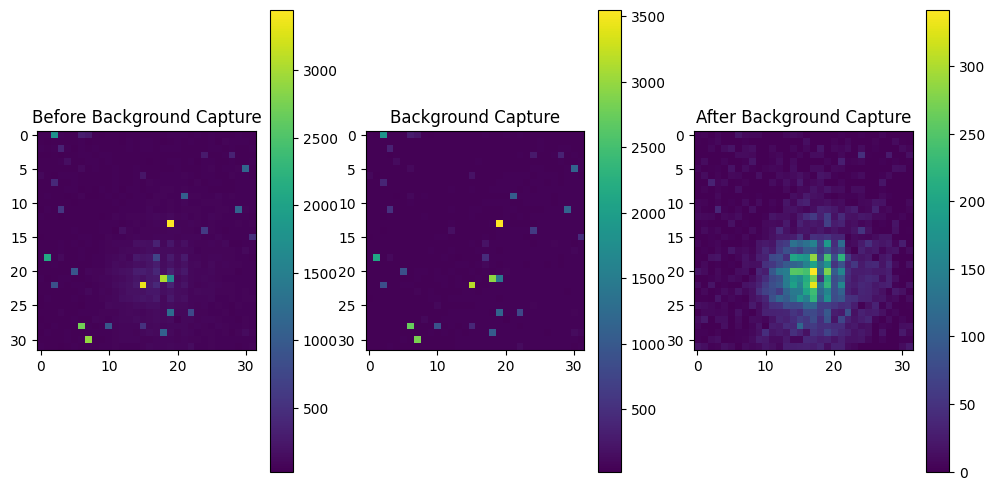

In [173]:
print(f"Background subtraction enabled: {spad._background_subtraction_enabled}")

plt.figure(figsize=(12,6))
plt.subplot(1,3,1)
plt.title("Before Background Capture")  
plt.imshow(before_bg)
plt.colorbar()
plt.subplot(1,3,2)
plt.title("Background Capture")  
plt.imshow(bg_frame)
plt.colorbar()
plt.subplot(1,3,3)
plt.title("After Background Capture")  
plt.imshow(after_bg)
plt.colorbar()

## Find Centroid and Center Image

In [174]:
# crop_dim = 14 # 14 pixels and 7 microns

# def find_centroid(image):
#     """Find the centroid of the bright spot in the image."""
#     M = cv2.moments(image)
#     if M["m00"] == 0:
#         return (image.shape[1] // 2, image.shape[0] // 2)  # Return center if no mass
#     cX = int(M["m10"] / M["m00"])
#     cY = int(M["m01"] / M["m00"])
#     return (cX, cY)

# init_image = np.array(get_frames(spad))
# init_image = np.flipud(init_image)
# centroid = find_centroid(init_image)
# x_center, y_center = centroid
# print(f"Centroid found at: ({x_center}, {y_center})")
# plt.imshow(init_image)

Current piezo position: {'x': 0.000176193, 'y': 2.59767e-05, 'z': 0.0001255879}


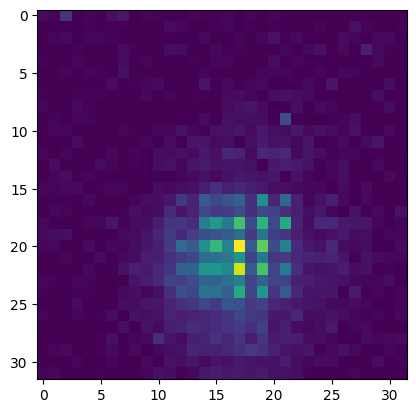

In [175]:
cur_pos = piezo.scanner_position
print("Current piezo position:", cur_pos)
frame = get_frames(spad)
plt.imshow(frame)

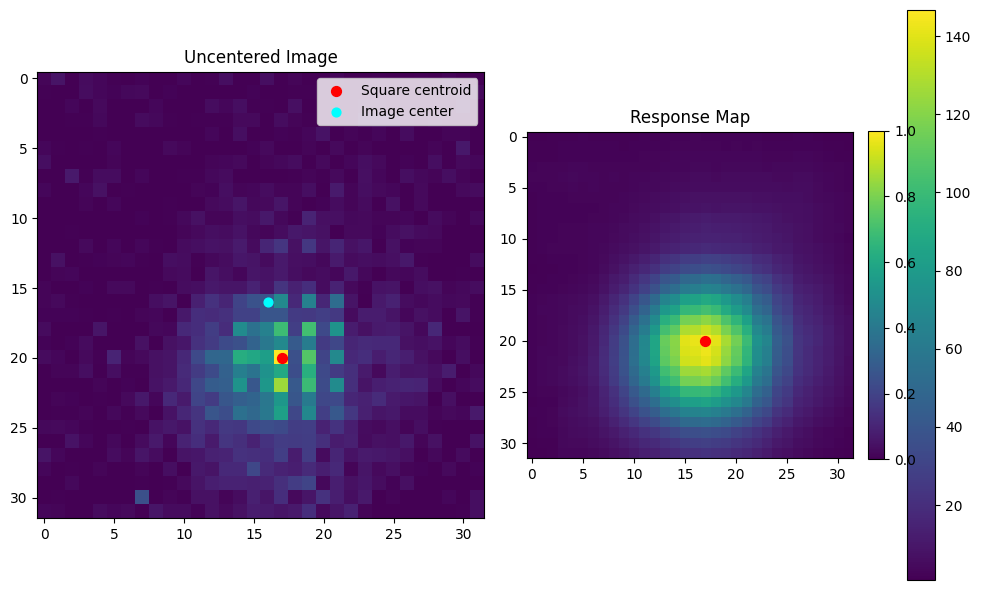

In [176]:
from scipy.signal import correlate2d
import numpy as np

def find_square(image, side):
    """
    Find the centroid of the bright square using a square kernel filter.
    Returns (cx, cy) in pixel coordinates and the response map.
    """
    kernel = np.ones((side, side), dtype=np.float32)
    kernel /= kernel.sum()  # normalize

    response = correlate2d(image.astype(np.float32), kernel, mode='same')

    cy, cx = np.unravel_index(np.argmax(response), response.shape)

    return cx, cy, response


def move_to_square(spad, piezo, nv_dim=5):
    """
    Move piezo so that the detected square (via kernel filtering) is centered.
    Returns response map and detected center.
    """
    image = get_frames(spad)
    h, w = image.shape

    side = nv_dim * 2 - 1
    blur = cv2.blur(image.astype(np.float32), (side, side))
    blur = np.clip(blur, 0, None)
    image -= blur
    cx_px, cy_px, response = find_square(image, side)

    dx_px = cx_px - w // 2
    dy_px = cy_px - h // 2

    dx_m = dx_px / 2.0 * 1e-6
    dy_m = dy_px / 2.0 * 1e-6

    pos = piezo.scanner_position.copy()
    pos["x"] = float(pos["x"]) - float(dx_m)
    pos["y"] = float(pos["y"]) - float(dy_m)
    piezo.set_target_position(pos, move_blocking=True)

    print(f"Pixel error: ({dx_px:.1f}, {dy_px:.1f}) px")
    print(f"Moved piezo by ({dx_m:.2e}, {dy_m:.2e}) m")

    return response, cx_px, cy_px

piezo.set_target_position(cur_pos, move_blocking=True)
nv_dim=5
frame_uncentered = get_frames(spad)
# response, x_center, y_center = move_to_square(spad, piezo, nv_dim=5)
side = nv_dim * 2 - 1
cx_square, cy_square, response = find_square(frame_uncentered, side=side)
# frame_centered = get_frames(spad)
h, w = frame_uncentered.shape

plt.figure(figsize=(10,6))

plt.subplot(1,2,1)
plt.title("Uncentered Image")
plt.imshow(frame_uncentered)
plt.scatter(cx_square, cy_square, color='red', s=50, label="Square centroid")
plt.scatter(w//2, h//2, color='cyan', s=40, label="Image center")
plt.legend()

plt.subplot(1,2,2)
plt.title("Response Map")
plt.imshow(response)
plt.colorbar()
plt.scatter(cx_square, cy_square, color='red', s=50)

# plt.subplot(1,3,3)
# plt.title("Centered Image")
# plt.imshow(frame_centered)
# plt.scatter(w//2, h//2, color='cyan', s=50, label="Image center")
# plt.legend()

plt.tight_layout()

plt.colorbar(ax=plt.gca(), fraction=0.046, pad=0.04)

In [177]:
# import cv2
# import numpy as np
# import matplotlib.pyplot as plt

# def threshold_percentile(img, percentile=95):
#     thresh_val = np.percentile(img, percentile)
#     bw = np.zeros_like(img, dtype=np.uint8)
#     bw[img >= thresh_val] = 255
#     return bw

# def threshold_otsu(img):
#     _, bw = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
#     return bw

# def threshold_adaptive_mean(img, block_size=3, C=-1):
#     return cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_MEAN_C,
#                                  cv2.THRESH_BINARY, block_size, C)

# def threshold_adaptive_gaussian(img, block_size=3, C=-1):
#     return cv2.adaptiveThreshold(img, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
#                                  cv2.THRESH_BINARY, block_size, C)

# def find_square(image, desired_area=81, threshold_func=threshold_percentile):
#     img8 = image.astype(np.uint8)
#     bw = threshold_func(img8)

#     num, labels, stats, centroids = cv2.connectedComponentsWithStats(bw)

#     valid_indices = [i for i in range(1, num)
#                      if desired_area*0.5 <= stats[i, cv2.CC_STAT_AREA] <= desired_area*1.5]

#     if not valid_indices:
#         print(f"No components found within 25% of desired area for {threshold_func.__name__}.")
#         return None, None, bw

#     i = max(valid_indices, key=lambda idx: stats[idx, cv2.CC_STAT_AREA])
#     cx, cy = centroids[i]
#     return cx, cy, bw

# def move_to_square(spad, piezo, nv_dim=5, threshold_func=threshold_percentile):
#     init_image = get_frames(spad)
#     init_image = np.flipud(init_image)
#     desired_area = (nv_dim * 2 - 1) ** 2

#     cx, cy, mask = find_square(init_image, desired_area=desired_area,
#                                threshold_func=threshold_func)

#     if cx is None:
#         print("No square found with this threshold.")
#         return mask

#     h, w = init_image.shape
#     x_offset = cx - w // 2
#     y_offset = cy - h // 2

#     x_offset_meters = x_offset / 2.0 * 1e-6
#     y_offset_meters = y_offset / 2.0 * 1e-6

#     pos_dict = piezo.scanner_position
#     pos_dict["x"] = float(pos_dict["x"]) + float(x_offset_meters)
#     pos_dict["y"] = float(pos_dict["y"]) + float(y_offset_meters)
#     piezo.set_target_position(pos_dict)

#     print(f"Center location: {pos_dict}")
#     print(f"Moved piezo by ({x_offset_meters} m, {y_offset_meters} m) to center the spot.")

#     return mask

# threshold_methods = {
#     "Percentile 95": threshold_percentile,
#     "Otsu": threshold_otsu,
# }

# init_image = get_frames(spad)
# init_image = np.flipud(init_image)
# desired_area = (5*2 - 1)**2

# plt.figure(figsize=(12, 8))
# plt.subplot(2, 3, 1)
# plt.title("Original Image")
# plt.imshow(init_image, cmap='inferno')
# plt.colorbar()

# for i, (name, func) in enumerate(threshold_methods.items(), start=2):
#     cx, cy, mask = find_square(init_image, desired_area=desired_area,
#                                threshold_func=func)
#     plt.subplot(2, 3, i)
#     plt.title(name)
#     plt.imshow(mask, cmap='gray')
#     if cx is not None:
#         plt.scatter(cx, cy, color='red', s=50)  # show centroid

# plt.tight_layout()
# plt.show()


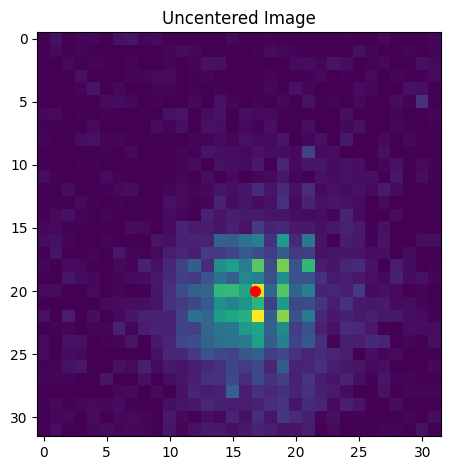

In [178]:
def find_centroid(image):
    M = cv2.moments(image)
    if M["m00"] == 0:
        return image.shape[1] // 2, image.shape[0] // 2
    cx = M["m10"] / M["m00"]
    cy = M["m01"] / M["m00"]
    return cx, cy

def move_to_centroid(spad, piezo, nv_dim=5):
    image = get_frames(spad)
    h, w = image.shape

    side = nv_dim * 2 - 1
    image_sub = image.astype(np.float32) - cv2.blur(image.astype(np.float32), (side, side))
    image_sub = np.clip(image_sub, 0, None)
    cx_px, cy_px = find_centroid(image_sub)

    dx_px = cx_px - w // 2
    dy_px = cy_px - h // 2

    dx_m = -dx_px / 2.0 * 1e-6
    dy_m = -dy_px / 2.0 * 1e-6

    pos = piezo.scanner_position.copy()
    pos["x"] = float(pos["x"]) + dx_m
    pos["y"] = float(pos["y"]) + dy_m

    piezo.set_target_position(pos, move_blocking=True)

    print(f"Pixel error: ({dx_px:.1f}, {dy_px:.1f}) px")
    print(f"Moved piezo by ({dx_m:.2e}, {dy_m:.2e}) m")

    return cx_px, cy_px


piezo.set_target_position(cur_pos, move_blocking=True)
frame_uncentered = get_frames(spad)
cx_centr, cy_centr = find_centroid(frame_uncentered)
# frame_centered = get_frames(spad)

h, w = frame_uncentered.shape

plt.plot()
plt.title("Uncentered Image")
plt.imshow(frame_uncentered)
plt.scatter(cx_centr, cy_centr, color='red', s=50)

# plt.subplot(1,2,2)
# plt.title("Centered Image")
# plt.imshow(frame_centered)
# plt.scatter(w//2, h//2, color='red', s=50)

plt.tight_layout()

In [179]:
cx, cy = cx_square, cy_square

In [180]:
# def sharpness_by_pixel(imgs):
#     imgs = torch.from_numpy(imgs).float().unsqueeze(1)

#     stride = (2, 2)
#     kernel = torch.ones((1, 1, 1, 1), dtype=imgs.dtype)

#     out = F.conv2d(imgs, kernel, stride=stride, padding=0)
#     brightness_frames = out.squeeze(1).cpu().numpy()

#     brightness_frames = brightness_frames / (brightness_frames.mean(axis=(1,2), keepdims=True) + 1e-6)

#     sharpness = []
#     brightness = []  # 1D: total brightness per z-position
#     for i in range(brightness_frames.shape[0]):
#         lap = cv2.Laplacian(brightness_frames[i], cv2.CV_32F)
#         sharpness.append(np.var(lap))
#         brightness.append(np.sum(brightness_frames[i]))  # Sum per frame

#     sharpness = np.array(sharpness)
#     brightness = np.array(brightness)
#     return sharpness, brightness

# def sharpness_global(imgs):
#     sharpness = []
#     brightness = []
#     for i in range(imgs.shape[0]):
#         img = imgs[i].astype(np.float32)
#         brightness.append(np.sum(img))  # Add brightness before normalization
        
#         img = img / (img.mean() + 1e-6)
#         img = cv2.GaussianBlur(img, (3,3), 0)
#         h, w = img.shape
#         roi = img[h//2-50:h//2+50, w//2-50:w//2+50]

#         lap = cv2.Laplacian(roi, cv2.CV_32F)
#         sharpness.append(np.var(lap))

#     sharpness = np.array(sharpness)
#     brightness = np.array(brightness)
#     return sharpness, brightness

# def sharpness_by_pixel(imgs):
#     imgs = torch.from_numpy(imgs).float().unsqueeze(1)

#     stride = (2, 2)
#     kernel = torch.ones((1, 1, 1, 1), dtype=imgs.dtype)

#     out = F.conv2d(imgs, kernel, stride=stride, padding=0)
#     brightness_frames = out.squeeze(1).cpu().numpy()

#     brightness_frames = brightness_frames / (brightness_frames.mean(axis=(1,2), keepdims=True) + 1e-6)

#     sharpness = []
#     brightness = []  # 1D: total brightness per z-position
#     for i in range(brightness_frames.shape[0]):
#         lap = cv2.Laplacian(brightness_frames[i], cv2.CV_32F)
#         sharpness.append(np.var(lap))
#         brightness.append(np.sum(brightness_frames[i]))  # Sum per frame

#     sharpness = np.array(sharpness)
#     brightness = np.array(brightness)
#     return sharpness, brightness

# def sharpness_global(imgs):
#     sharpness = []
#     brightness = []
#     for i in range(imgs.shape[0]):
#         img = imgs[i].astype(np.float32)
#         brightness.append(np.sum(img))  # Add brightness before normalization
        
#         img = img / (img.mean() + 1e-6)
#         img = cv2.GaussianBlur(img, (3,3), 0)
#         h, w = img.shape
#         roi = img[h//2-50:h//2+50, w//2-50:w//2+50]

#         lap = cv2.Laplacian(roi, cv2.CV_32F)
#         sharpness.append(np.var(lap))

#     sharpness = np.array(sharpness)
#     brightness = np.array(brightness)
#     return sharpness, brightness

## Building the Sequence

In [181]:
arr_dim = 5
resolution_z = 100 # pixels
init_pos = piezo.scanner_position
scan_range_z = 10.0e-6
z_l_bound, z_u_bound = piezo.scanner_constraints.axes['z'].position.bounds

start_z = init_pos['z'] - scan_range_z / 2
sequence_z = np.linspace(start_z, start_z + scan_range_z, int(resolution_z))

if sequence_z[0] < z_l_bound or sequence_z[-1] > z_u_bound:
    raise ValueError(f"Z scan range [{sequence_z[0]:.2e}, {sequence_z[-1]:.2e}] m exceeds scanner bounds [{z_l_bound:.2e}, {z_u_bound:.2e}] m")

w, h = spad.get_size()
array_size_microns = 2 * arr_dim - 1 
pxl_per_micron_x = w / array_size_microns  # 32 pixels / 9 microns = 3.56 pxl/micron
pxl_per_micron_y = h / array_size_microns

## Capture Images in Sequence

In [182]:
crop_dim = 14
img_samples_Z = np.zeros((resolution_z, crop_dim, crop_dim), dtype=np.float32)
pos_dict = {k: float(v) for k, v in init_pos.items()}

# Use the previously determined centroid (cx, cy)
for idx, z_sample in enumerate(sequence_z):
    pos_dict['z'] = float(z_sample)

    position = piezo.set_target_position(pos_dict, move_blocking=True)
    time.sleep(0.5)
    frame = get_frames(spad, n_frames=1)
    # Calculate integer crop bounds centered on (cx, cy)
    x0 = int(round(cx - crop_dim // 2))
    y0 = int(round(cy - crop_dim // 2))
    x1 = x0 + crop_dim
    y1 = y0 + crop_dim
    # Clip to image boundaries
    x0 = max(0, min(x0, frame.shape[1] - crop_dim))
    y0 = max(0, min(y0, frame.shape[0] - crop_dim))
    x1 = x0 + crop_dim
    y1 = y0 + crop_dim
    frame_cropped = frame[y0:y1, x0:x1]
    img_samples_Z[idx, :, :] = frame_cropped.astype(np.float32)
    print(f"Captured frame {idx+1}/{resolution_z} (crop center: {cx:.1f}, {cy:.1f})")

print(f"Final shape: {img_samples_Z.shape}")

Captured frame 1/100 (crop center: 17.0, 20.0)
Captured frame 2/100 (crop center: 17.0, 20.0)
Captured frame 3/100 (crop center: 17.0, 20.0)
Captured frame 4/100 (crop center: 17.0, 20.0)
Captured frame 5/100 (crop center: 17.0, 20.0)
Captured frame 6/100 (crop center: 17.0, 20.0)
Captured frame 7/100 (crop center: 17.0, 20.0)
Captured frame 8/100 (crop center: 17.0, 20.0)
Captured frame 9/100 (crop center: 17.0, 20.0)
Captured frame 10/100 (crop center: 17.0, 20.0)
Captured frame 11/100 (crop center: 17.0, 20.0)
Captured frame 12/100 (crop center: 17.0, 20.0)
Captured frame 13/100 (crop center: 17.0, 20.0)
Captured frame 14/100 (crop center: 17.0, 20.0)
Captured frame 15/100 (crop center: 17.0, 20.0)
Captured frame 16/100 (crop center: 17.0, 20.0)
Captured frame 17/100 (crop center: 17.0, 20.0)
Captured frame 18/100 (crop center: 17.0, 20.0)
Captured frame 19/100 (crop center: 17.0, 20.0)
Captured frame 20/100 (crop center: 17.0, 20.0)
Captured frame 21/100 (crop center: 17.0, 20.0)
C

## Calculating Optimal Position Using Sharpness and Focus Metrics

### Finding Position of Best Focus

In [183]:
img_samples_Z = np.nan_to_num(img_samples_Z, 0)
"""
Apply a kernel of 1 pixel with stride of 2 pixels.
"""

# def sharpness_by_pixel(imgs):
#     imgs = torch.from_numpy(imgs).float().unsqueeze(1)

#     stride = (2, 2)
#     kernel = torch.ones((1, 1, 1, 1), dtype=imgs.dtype)

#     out = F.conv2d(imgs, kernel, stride=stride, padding=0)
#     brightness_frames = out.squeeze(1).cpu().numpy()

#     brightness_frames = brightness_frames / (brightness_frames.mean(axis=(1,2), keepdims=True) + 1e-6)

#     sharpness = []
#     brightness = []  # 1D: total brightness per z-position
#     for i in range(brightness_frames.shape[0]):
#         lap = cv2.Laplacian(brightness_frames[i], cv2.CV_32F)
#         sharpness.append(np.var(lap))
#         brightness.append(np.sum(brightness_frames[i]))  # Sum per frame

#     sharpness = np.array(sharpness)
#     brightness = np.array(brightness)
#     return sharpness, brightness


def sharpness_checkerboard(imgs, method="contrast"):
    sharpness = []
    brightness = []

    for img in imgs:
        img = img.astype(np.float32)
        brightness.append(np.sum(img))  # physical brightness

        # normalize for focus metric only
        img = img / (img.mean() + 1e-6)

        if method == "contrast":
            dx = img[:, 1:] - img[:, :-1]
            dy = img[1:, :] - img[:-1, :]
            s = np.mean(dx * dx) + np.mean(dy * dy)

        elif method == "fft":
            F = np.fft.fftshift(np.fft.fft2(img))
            power = np.abs(F) ** 2

            # Nyquist corners (highest spatial frequencies)
            s = (
                power[0, 0]
                + power[0, -1]
                + power[-1, 0]
                + power[-1, -1]
            )

        else:
            raise ValueError("Unknown method")

        sharpness.append(s)

    return np.array(sharpness)

def focus_global(imgs):
    sharpness = []
    brightness = []
    for i in range(imgs.shape[0]):
        img = imgs[i].astype(np.float32)
        brightness.append(np.sum(img))  # Add brightness before normalization
        
        img = img / (img.mean() + 1e-6)
        img = cv2.GaussianBlur(img, (3,3), 0)
        h, w = img.shape

        lap = cv2.Laplacian(img, cv2.CV_32F)
        sharpness.append(np.var(lap))

    sharpness = np.array(sharpness)
    brightness = np.array(brightness)
    return sharpness, brightness

# Calculate focus metrics
focus_contrast = sharpness_checkerboard(
    img_samples_Z, method="contrast"
)

focus_fft = sharpness_checkerboard(
    img_samples_Z, method="fft"
)

sharpness_global, brightness_global = focus_global(img_samples_Z)

idx_global_bright = np.argmax(brightness_global)

idx_contrast_focus = np.argmax(focus_contrast)
idx_fft_focus = np.argmax(focus_fft)
idx_global_focus = np.argmax(sharpness_global)

print(f"Original: {img_samples_Z.shape}")

print(f"\n=== Sharpness Metric ===")
print(f"Contrast-based: Range [{focus_contrast.min():.2f}, {focus_contrast.max():.2f}], "
      f"Peak @ z={sequence_z[idx_contrast_focus]*1e6:.3f} µm")
print(f"FFT-based:      Range [{focus_fft.min():.2f}, {focus_fft.max():.2f}], "
      f"Peak @ z={sequence_z[idx_fft_focus]*1e6:.3f} µm")
print(f"Global-based:   Range [{sharpness_global.min():.2f}, {sharpness_global.max():.2f}], "
      f"Peak @ z={sequence_z[idx_global_focus]*1e6:.3f} µm")

print(f"\n=== Brightness Metric ===")
print(f"Global-based:   Range [{brightness_global.min():.0f}, {brightness_global.max():.0f}], "
      f"Peak @ z={sequence_z[idx_global_bright]*1e6:.3f} µm")

Original: (100, 14, 14)

=== Sharpness Metric ===
Contrast-based: Range [0.12, 2.56], Peak @ z=125.032 µm
FFT-based:      Range [4.90, 2537.62], Peak @ z=125.032 µm
Global-based:   Range [0.02, 0.11], Peak @ z=124.830 µm

=== Brightness Metric ===
Global-based:   Range [11500, 18498], Peak @ z=126.649 µm


### Compare Focus Methods

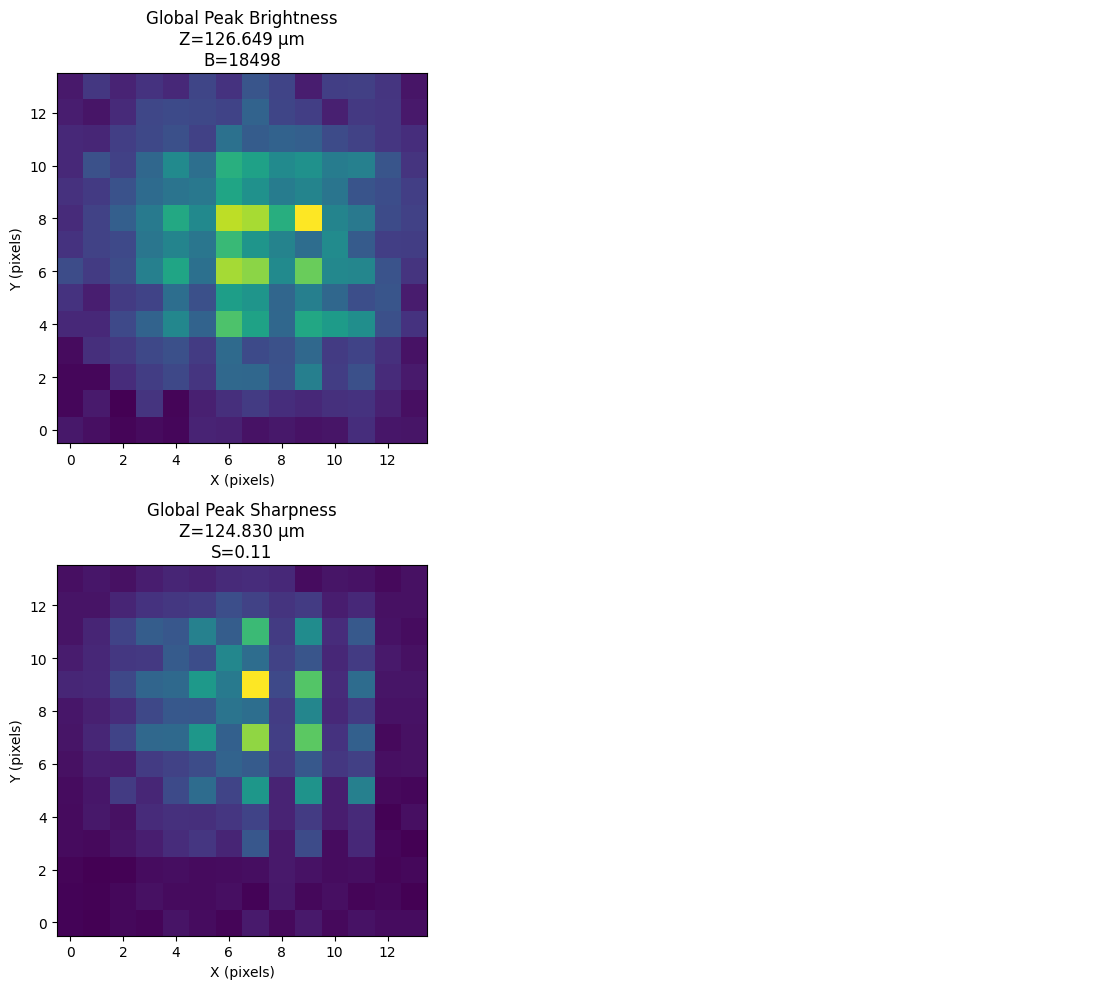


=== Peak Brightness Position ===
Global:   Z=126.649 µm (idx 60)

=== Peak Sharpness Position ===
Global:   Z=124.830 µm (idx 42)

=== Brightness vs Sharpness Agreement ===
Global:   |Δ| = 18 frames


In [184]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Peak images (only global brightness and sharpness)
img_global_bright   = img_samples_Z[idx_global_bright]
img_global_focus    = img_samples_Z[idx_global_focus]

# --------------------
# Peak Brightness Row
# --------------------
axes[0, 0].imshow(img_global_bright, origin="lower")
axes[0, 0].set_title(
    f"Global Peak Brightness\n"
    f"Z={sequence_z[idx_global_bright]*1e6:.3f} µm\n"
    f"B={brightness_global[idx_global_bright]:.0f}"
)
axes[0, 0].set_ylabel("Y (pixels)")

axes[0, 1].axis('off')  # No other brightness metrics

# ----------------
# Peak Focus Row
# ----------------
axes[1, 0].imshow(img_global_focus, origin="lower")
axes[1, 0].set_title(
    f"Global Peak Sharpness\n"
    f"Z={sequence_z[idx_global_focus]*1e6:.3f} µm\n"
    f"S={sharpness_global[idx_global_focus]:.2f}"
)
axes[1, 0].set_ylabel("Y (pixels)")

axes[1, 1].axis('off')  # No other sharpness metrics

for ax in axes.flat:
    ax.set_xlabel("X (pixels)")

plt.tight_layout()
plt.show()

print("\n=== Peak Brightness Position ===")
print(f"Global:   Z={sequence_z[idx_global_bright]*1e6:.3f} µm (idx {idx_global_bright})")

print("\n=== Peak Sharpness Position ===")
print(f"Global:   Z={sequence_z[idx_global_focus]*1e6:.3f} µm (idx {idx_global_focus})")

print("\n=== Brightness vs Sharpness Agreement ===")
print(f"Global:   |Δ| = {abs(idx_global_bright - idx_global_focus)} frames")

In [185]:
focus_metric_Z = brightness_global

In [186]:
# idx_max = np.argmax(focus_metric_Z)
# print(f"Best focus index: {idx_max}")
# print(f"Focus metric value: {focus_metric_Z[idx_max]:.2f}")
# pos_z_max = sequence_z[idx_max]

# pos_dict['z'] = float(pos_z_max)
# position = piezo.set_target_position(pos_dict, move_blocking=True)

# frames = []
# for i in range(5):
#     single_frame = np.array(spad.start_single_acquisition()[0, 0, :, :])
#     frames.append(single_frame)
#     print(f"Captured frame {i+1}/5")

# frame = np.mean(frames, axis=0)
# total_brightness = np.sum(frame)

# plt.figure(figsize=(8, 6))
# plt.imshow(np.flipud(frame), origin='lower')
# plt.colorbar(label='Counts')
# plt.title(f'Best Focus Position: Z = {pos_z_max*1e6:.3f} µm\nFocus Metric: {focus_metric_Z[idx_max]:.2f}\nTotal Brightness: {total_brightness:.0f} (avg of 5 frames)')
# plt.xlabel('X (pixels)')
# plt.ylabel('Y (pixels)')
# plt.show()

# print(f"Position index: {idx_max}")
# print(f"Physical position: z={pos_z_max*1e6:.3f} µm")
# print(f"Focus metric from scan: {focus_metric_Z[idx_max]:.2f}")
# print(f"Total frame brightness: {total_brightness:.0f}")

### Compare Images at Different Focus Metrics' Peaks

In [187]:
# fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# idx_kernel = np.argmax(focus_kernel)
# img_kernel = img_samples_Z[idx_kernel]

# idx_laplacian = np.argmax(focus_laplacian_grid)
# img_laplacian = img_samples_Z[idx_laplacian]

# axes[0].imshow(np.flipud(img_kernel), origin='lower')
# axes[0].set_title(f'Kernel-Based Peak\nZ = {sequence_z[idx_kernel]*1e6:.3f} µm, Metric = {focus_kernel[idx_kernel]:.2f}', fontsize=11)
# axes[0].set_xlabel('X (pixels)')
# axes[0].set_ylabel('Y (pixels)')

# axes[1].imshow(np.flipud(img_laplacian), origin='lower')
# axes[1].set_title(f'Laplacian Grid Peak\nZ = {sequence_z[idx_laplacian]*1e6:.3f} µm, Metric = {focus_laplacian_grid[idx_laplacian]:.2f}', fontsize=11)
# axes[1].set_xlabel('X (pixels)')
# axes[1].set_ylabel('Y (pixels)')

# plt.tight_layout()
# plt.show()

# print(f"\n=== Peak Position Comparison ===")
# print(f"Kernel-based:  Z = {sequence_z[idx_kernel]*1e6:.3f} µm (index {idx_kernel})")
# print(f"Laplacian Grid: Z = {sequence_z[idx_laplacian]*1e6:.3f} µm (index {idx_laplacian})")
# print(f"Difference: {abs(sequence_z[idx_kernel] - sequence_z[idx_laplacian])*1e6:.3f} µm ({abs(idx_kernel - idx_laplacian)} frames)")

## Fitting to a Gaussian Distribution

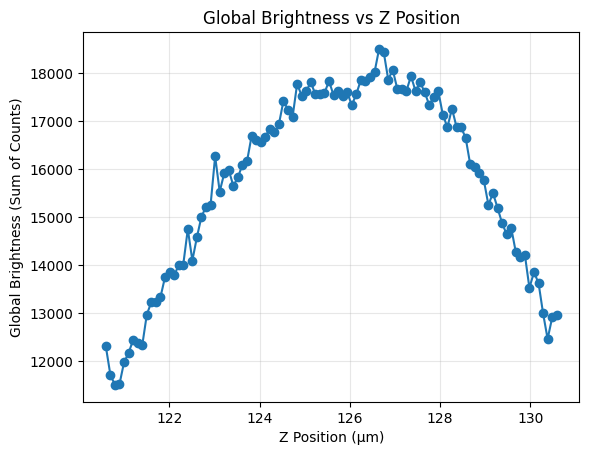

In [188]:
brightness_Z = brightness_global

plt.plot(sequence_z * 1e6, brightness_Z, marker='o', linestyle='-')
plt.xlabel("Z Position (µm)")
plt.ylabel("Global Brightness (Sum of Counts)")
plt.title("Global Brightness vs Z Position")
plt.grid(True, alpha=0.3)
plt.show()

In [189]:
def gaussian(x, amp, mu, sigma, offset):
    return amp * np.exp(-(x - mu)**2 / (2 * sigma**2)) + offset

p0 = [
    focus_metric_Z.max() - focus_metric_Z.min(), # amplitude
    sequence_z[np.argmax(focus_metric_Z)], # center
    np.std(sequence_z), # width
    focus_metric_Z.min() # offset
]

bounds_z = (
    [0.0, sequence_z[0], 1e-12, -np.inf], 
    [np.inf, sequence_z[-1], np.inf, np.inf]
)

popt, _ = curve_fit(gaussian, sequence_z, focus_metric_Z, p0=p0, bounds=bounds_z)

# sse = float(np.sum(resid**2))
# sst = float(np.sum((nv_brightness - np.mean(nv_brightness))**2))
# r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")
# rmse = float(np.sqrt(np.mean(resid**2)))
A_fit, z_fit, sigma, C_fit = popt
pos_dict['z'] = float(z_fit)
position = piezo.set_target_position(pos_dict, move_blocking=True)
time.sleep(1)

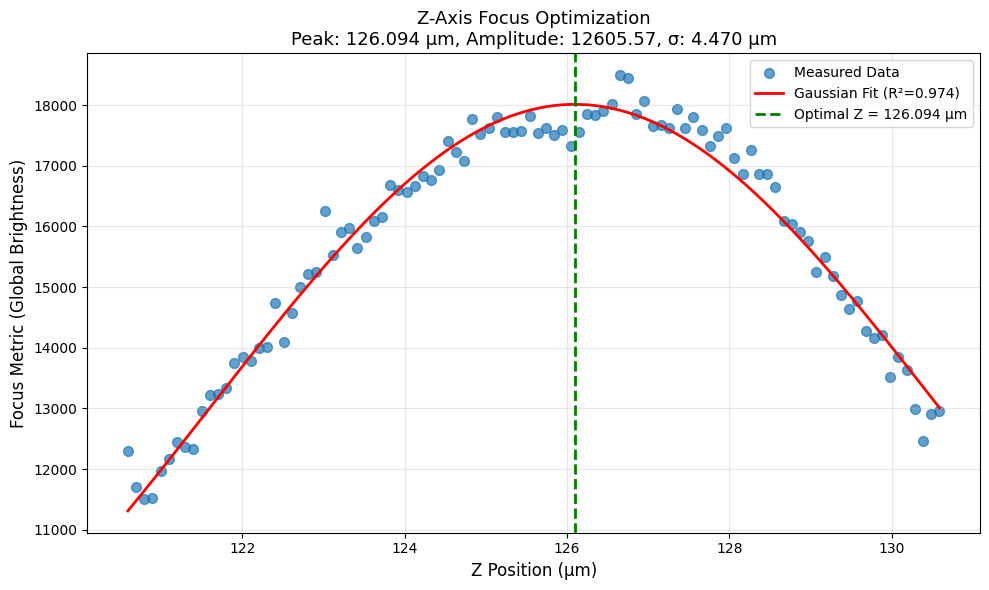

Optimal Z position: 126.094 µm (1.260937e-04 m)
Gaussian width (σ): 4.470 µm
Focus amplitude: 12605.57, Background: 5407.49
R²: 0.9740, RMSE: 315.6712


In [190]:
x_axis = np.linspace(min(sequence_z), max(sequence_z), 500)
y_axis = gaussian(x_axis, *popt)

resid = focus_metric_Z - gaussian(sequence_z, *popt)
sse = float(np.sum(resid**2))
sst = float(np.sum((focus_metric_Z - np.mean(focus_metric_Z))**2))
r2 = 1.0 - (sse / sst) if sst > 0 else float("nan")
rmse = float(np.sqrt(np.mean(resid**2)))

plt.figure(figsize=(10, 6))
plt.scatter(sequence_z * 1e6, focus_metric_Z, label="Measured Data", s=50, alpha=0.7)
plt.plot(x_axis * 1e6, y_axis, 'r-', label=f"Gaussian Fit (R²={r2:.3f})", linewidth=2)
plt.axvline(z_fit * 1e6, color='green', linestyle='--', linewidth=2, label=f'Optimal Z = {z_fit*1e6:.3f} µm')
plt.xlabel("Z Position (µm)", fontsize=12)
plt.ylabel("Focus Metric (Global Brightness)", fontsize=12)
plt.title(f"Z-Axis Focus Optimization\nPeak: {z_fit*1e6:.3f} µm, Amplitude: {A_fit:.2f}, σ: {sigma*1e6:.3f} µm", fontsize=13)
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Optimal Z position: {z_fit*1e6:.3f} µm ({z_fit:.6e} m)")
print(f"Gaussian width (σ): {sigma*1e6:.3f} µm")
print(f"Focus amplitude: {A_fit:.2f}, Background: {C_fit:.2f}")
print(f"R²: {r2:.4f}, RMSE: {rmse:.4f}")

Captured frame 1/5
Captured frame 2/5
Captured frame 3/5
Captured frame 4/5
Captured frame 5/5


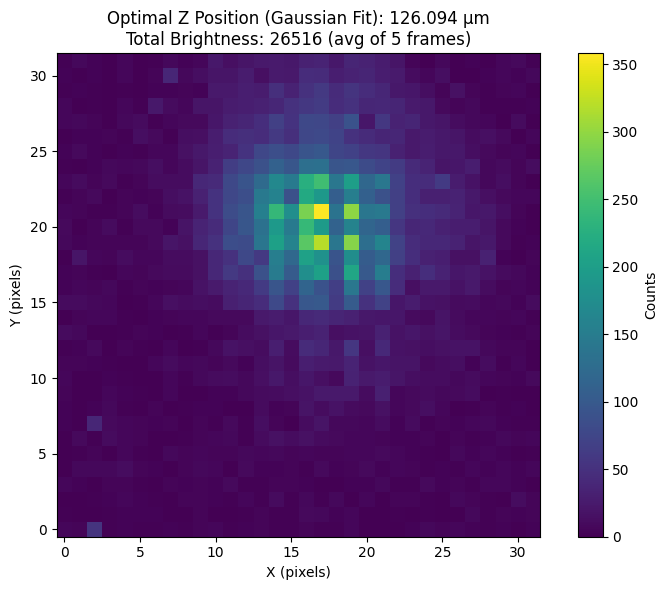


Image captured at optimal Z = 126.094 µm
Total brightness: 26516 counts


In [191]:
try:
    frames = get_frames(spad, n_frames=5)
except:
    frames = []
    for i in range(5):
        single_frame = get_frames(spad, n_frames=1)
        frames.append(single_frame)
        print(f"Captured frame {i+1}/5")
frame_avg = np.mean(frames, axis=0)
total_brightness = np.sum(frame_avg)

plt.figure(figsize=(8, 6))
plt.imshow(frame_avg, origin='lower')
plt.colorbar(label='Counts')
plt.title(f'Optimal Z Position (Gaussian Fit): {z_fit*1e6:.3f} µm\nTotal Brightness: {total_brightness:.0f} (avg of 5 frames)')
plt.xlabel('X (pixels)')
plt.ylabel('Y (pixels)')
plt.tight_layout()
plt.show()

print(f"\nImage captured at optimal Z = {z_fit*1e6:.3f} µm")
print(f"Total brightness: {total_brightness:.0f} counts")

In [192]:
# Calculate focus metric for optimized position (use cropped images for both initial and final)
final_focus_metric, final_brightness_metric = focus_global(frame_avg.reshape(1, frame_avg.shape[0], frame_avg.shape[1]))

piezo.set_target_position(cur_pos, move_blocking=True)
time.sleep(1)
initial_images_full = get_frames(spad, n_frames=1)

# Crop initial image using same center and crop_dim as in the scan
crop_dim = frame_avg.shape[0]  # or use the same crop_dim variable as above
x0 = int(round(cx - crop_dim // 2))
y0 = int(round(cy - crop_dim // 2))
x0 = max(0, min(x0, initial_images_full.shape[1] - crop_dim))
y0 = max(0, min(y0, initial_images_full.shape[0] - crop_dim))
x1 = x0 + crop_dim
y1 = y0 + crop_dim
initial_images = initial_images_full[y0:y1, x0:x1]

initial_focus_Z, initial_brightness_Z = focus_global(initial_images.reshape(1, crop_dim, crop_dim))
initial_focus_Z = initial_focus_Z.mean()
initial_brightness_Z = initial_brightness_Z.mean()

print(f"\n=== Optimization Results ===")
print(f"Starting sharpness metric: {initial_focus_Z:.2f}")
print(f"Final sharpness metric: {final_focus_metric[0]:.2f}")
print(f"Sharpness improvement: {((final_focus_metric[0] - initial_focus_Z) / initial_focus_Z * 100):.1f}%")
print(f"\nStarting brightness: {initial_brightness_Z:.0f} counts")
print(f"Final brightness: {final_brightness_metric[0]:.0f} counts")
print(f"Brightness change: {((final_brightness_metric[0] - initial_brightness_Z) / initial_brightness_Z * 100):.1f}%")

if final_brightness_metric[0] < initial_brightness_Z * 0.95:  # Allow 5% tolerance
    print("\nOptimization may have failed (brightness decreased). Reverting to original position.")
    piezo.set_target_position(cur_pos, move_blocking=True)
else:
    print(f"\nOptimization successful! Brightness improved.")


=== Optimization Results ===
Starting sharpness metric: 0.19
Final sharpness metric: 0.12
Sharpness improvement: -37.3%

Starting brightness: 25127 counts
Final brightness: 26516 counts
Brightness change: 5.5%

Optimization successful! Brightness improved.


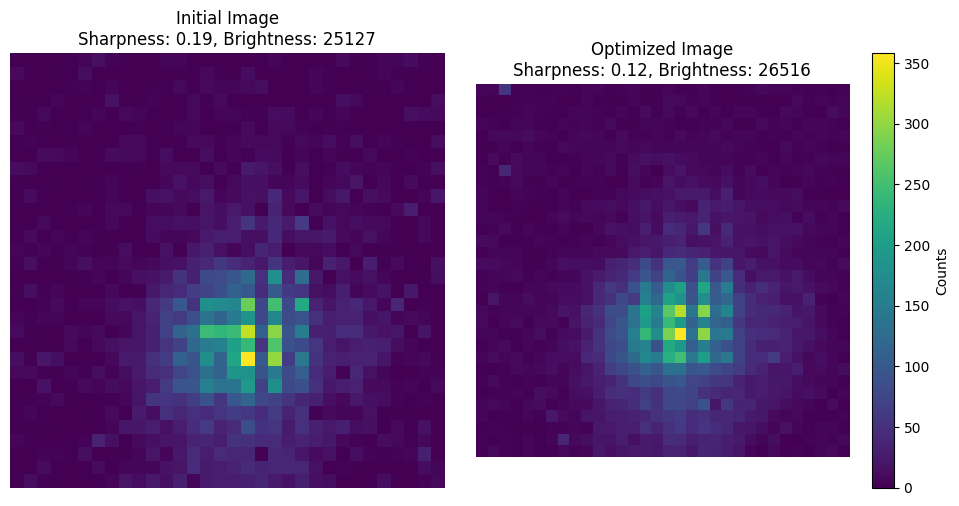

In [193]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title(f"Initial Image\nSharpness: {initial_focus_Z:.2f}, Brightness: {initial_brightness_Z:.0f}")
plt.imshow(initial_images)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"Optimized Image\nSharpness: {final_focus_metric[0]:.2f}, Brightness: {final_brightness_metric[0]:.0f}")
plt.imshow(frame_avg)
plt.axis('off')

plt.colorbar(label='Counts')

plt.tight_layout()
plt.show()